# Predictive Modeling 

## 1. Regression 

We start with a regression task using the `Hitters` dataset from the `ISLR` package. The goal is to predict player salary using hitting statistics.

### 1.1 Load and Prepare the Data

In [2]:
library(ISLR)
library(dplyr)

hitters <- na.omit(Hitters)  # remove rows with missing values

df_reg <- hitters %>%
  select(Salary, Hits, Years, Walks)
head(df_reg)

Warning message:
"package 'ISLR' was built under R version 4.3.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




,Salary,Hits,Years,Walks
,<dbl>,<int>,<int>,<int>
-Alan Ashby,475.0,81,14,39
-Alvin Davis,480.0,130,3,76
-Andre Dawson,500.0,141,11,37
-Andres Galarraga,91.5,87,2,30
-Alfredo Griffin,750.0,169,11,35
-Al Newman,70.0,37,2,21


### 1.2 Train/Test Split

We randomly select 70% of the data for training, and use the remaining 30% for testing.

In [3]:
set.seed(1)  # for reproducibility
n <- nrow(df_reg)
train_idx <- sample(seq_len(n), size = 0.7 * n)

train <- df_reg[train_idx, ]
test  <- df_reg[-train_idx, ]
nrow(train); nrow(test)

[1] 184

[1] 79

### 1.3 Fit a Linear Regression Model

We fit a linear regression model to predict `Salary` using `Hits` and `Years`.

In [4]:
model_reg <- lm(Salary ~ Hits + Years, data = train)
summary(model_reg)


Call:
lm(formula = Salary ~ Hits + Years, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-797.71 -214.64  -47.85   77.99 2206.68 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -159.4255    82.9366  -1.922   0.0561 .  
Hits           3.8980     0.6069   6.423 1.14e-09 ***
Years         38.0926     6.2786   6.067 7.44e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 372.4 on 181 degrees of freedom
Multiple R-squared:  0.2982,	Adjusted R-squared:  0.2904 
F-statistic: 38.45 on 2 and 181 DF,  p-value: 1.214e-14


### 1.4 Predict on the Test Set

In [5]:
pred_reg <- predict(model_reg, newdata = test)
head(pred_reg)

-Andre Dawson -Andres Galarraga        -Al Newman  -Argenis Salazar 
        809.20857         255.88424          60.98506         239.40505 
   -Andres Thomas     -Alex Trevino 
        232.49634         390.00086

### 1.5 Evaluate Predictions with RMSE

Root Mean Squared Error (RMSE) measures the typical size of prediction errors on the test set.

In [6]:
rmse <- sqrt(mean((pred_reg - test$Salary)^2))
rmse

[1] 352.9453

### 1.6 Plot Actual vs Predicted Salary

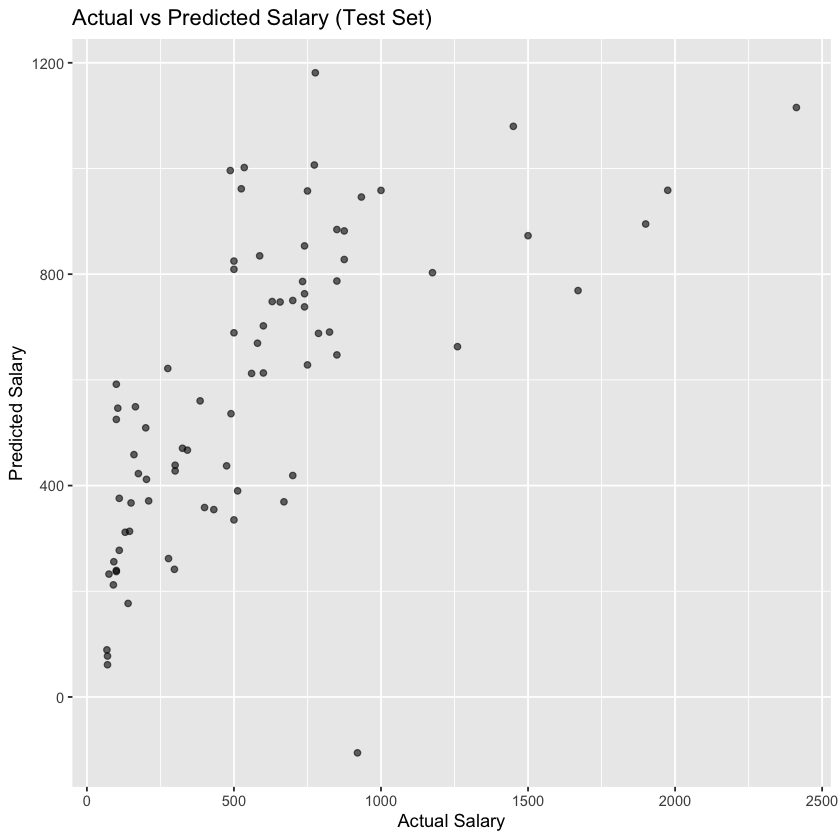

In [7]:
library(ggplot2)

ggplot(data.frame(actual = test$Salary, pred = pred_reg),
       aes(x = actual, y = pred)) +
  geom_point(alpha = 0.6) +
  labs(x = "Actual Salary", y = "Predicted Salary",
       title = "Actual vs Predicted Salary (Test Set)")

### 1.7 Coding Exercises (Regression)

**Exercise A**

Add an extra predictor (`Walks`) to the model and compare RMSE.

```r
model_reg2 <- lm(Salary ~ Hits + Years + Walks, data = train)
pred_reg2  <- predict(model_reg2, newdata = test)
rmse2 <- sqrt(mean((pred_reg2 - test$Salary)^2))
rmse2
```

Compare `rmse` and `rmse2`. Which model predicts better on the test set?

**Exercise B**

Try changing the training proportion (e.g., 60% train / 40% test) and see how RMSE changes.

## 2. Classification Example

Now we move to a classification task using the `Smarket` dataset from the `ISLR` package. The goal is to predict whether the market goes up or down.

### 2.1 Load and Inspect the Data

In [8]:
library(ISLR)
data(Smarket)
df_clf <- Smarket
head(df_clf)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
6,2001,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up


### 2.2 Train/Test Split

We again use a 70% / 30% train/test split.

In [9]:
set.seed(1)
n <- nrow(df_clf)
train_idx <- sample(seq_len(n), size = 0.7 * n)

train <- df_clf[train_idx, ]
test  <- df_clf[-train_idx, ]
nrow(train); nrow(test)

[1] 875

[1] 375

### 2.3 Fit a Logistic Regression Model

We predict `Direction` (Up/Down) using `Lag1` and `Lag2` as predictors.

In [10]:
model_clf <- glm(Direction ~ Lag1 + Lag2,
                 data = train,
                 family = binomial)
summary(model_clf)


Call:
glm(formula = Direction ~ Lag1 + Lag2, family = binomial, data = train)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.04396    0.06769   0.649    0.516
Lag1        -0.06527    0.05993  -1.089    0.276
Lag2        -0.02861    0.06038  -0.474    0.636

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1212.6  on 874  degrees of freedom
Residual deviance: 1211.2  on 872  degrees of freedom
AIC: 1217.2

Number of Fisher Scoring iterations: 3


### 2.4 Predict Class Probabilities on the Test Set

In [11]:
prob <- predict(model_clf, newdata = test, type = "response")
head(prob)

1         4         9        10        12        14 
0.5061474 0.5137700 0.5134298 0.4895389 0.5170566 0.5012476

### 2.5 Convert Probabilities to Class Labels

We classify as `Up` if the predicted probability is greater than 0.5, and `Down` otherwise.

In [12]:
pred_clf <- ifelse(prob > 0.5, "Up", "Down")
head(pred_clf)

1      4      9     10     12     14 
  "Up"   "Up"   "Up" "Down"   "Up"   "Up"

### 2.6 Compute Classification Accuracy

In [13]:
accuracy <- mean(pred_clf == test$Direction)
accuracy

[1] 0.5333333

### 2.7 Confusion Matrix

In [14]:
table(Predicted = pred_clf, Actual = test$Direction)

         Actual
Predicted Down  Up
     Down   44  45
     Up    130 156

### 2.8 Guided Coding Exercises (Classification)

**Exercise C**

Add `Lag3` as an additional predictor and see if accuracy improves.

```r
model_clf2 <- glm(Direction ~ Lag1 + Lag2 + Lag3,
                  data = train,
                  family = binomial)
prob2 <- predict(model_clf2, newdata = test, type = "response")
pred2 <- ifelse(prob2 > 0.5, "Up", "Down")
mean(pred2 == test$Direction)
```

**Exercise D**

Try a different classification threshold, such as 0.45:

```r
pred45 <- ifelse(prob > 0.45, "Up", "Down")
mean(pred45 == test$Direction)
```

Compare the accuracy at threshold 0.5 vs 0.45.

## 3. Code Templates 

### 3.1 Train/Test Split Template

```r
set.seed(SEED)
n <- nrow(df)
train_idx <- sample(seq_len(n), size = TRAIN_FRAC * n)

train <- df[train_idx, ]
test  <- df[-train_idx, ]
```
Replace `SEED`, `df`, and `TRAIN_FRAC` as needed.

### 3.2 Regression Template

```r
model <- lm(Y ~ X1 + X2 + ..., data = train)
pred  <- predict(model, newdata = test)
rmse  <- sqrt(mean((pred - test$Y)^2))
```
Replace `Y`, `X1`, `X2`, etc. with your actual variable names.

### 3.3 Classification (Logistic Regression) Template

```r
model <- glm(Y ~ X1 + X2 + ..., family = binomial, data = train)
prob  <- predict(model, newdata = test, type = "response")
pred  <- ifelse(prob > 0.5, 1, 0)   # or labels like "Up"/"Down"
accuracy <- mean(pred == test$Y)
```
Again, replace `Y`, `X1`, `X2`, etc. with the names from your homework dataset.